<a href="https://colab.research.google.com/github/SharonDarla/Phishing-URL-detector/blob/main/Phishing_URL_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# List files in the root directory of Google Drive
!ls /content/drive/MyDrive/Phishing_URL_detector/combined_dataset.csv

/content/drive/MyDrive/Phishing_URL_detector/combined_dataset.csv


In [ ]:
# Load the dataset
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Phishing_URL_detector/combined_dataset.csv')
print(df.head())

                                              domain   ranking  isIp  valid  \
0                               www.voting-yahoo.com  10000000     0      0   
1         www.zvon.org/xxl/WSDL1.1/Output/index.html    194914     0      1   
2  tecportais.com/file-security-update-infonfmati...  10000000     0      0   
3                bima.astro.umd.edu/nemo/linuxastro/      7001     0      0   
4  huarui-tec.com/js/?us.battle.net/login/en/?ref...  10000000     0      1   

   activeDuration  urlLen  is@  isredirect  haveDash  domainLen  \
0               0      20    0           0         1         20   
1            7305      42    0           0         0         12   
2               0     155    0           0         0         14   
3               0      35    0           0         0         18   
4             730      79    0           0         1         14   

   nosOfSubdomain  label  
0               2      1  
1               2      0  
2               1      1  
3             

In [ ]:
# Separate features and labels
X = df.drop(['label', 'domain'], axis=1)  # Exclude 'label' and 'domain' columns
Y = df['label']

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search for Random Forest
rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid_search.fit(X_train, Y_train)
best_rf_model = rf_grid_search.best_estimator_

# Define parameter grid for Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}

# Grid Search for Gradient Boosting
gb_grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gb_grid_search.fit(X_train, Y_train)
best_gb_model = gb_grid_search.best_estimator_

In [ ]:
# Convert labels to categorical one-hot encoding
Y_train_categorical = to_categorical(Y_train, num_classes=2)
Y_test_categorical = to_categorical(Y_test, num_classes=2)

# Initialize and train the Sequential Neural Network
nn_model = Sequential()
nn_model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
nn_model.add(Dropout(0.5))
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dropout(0.5))
nn_model.add(Dense(2, activation='softmax'))

nn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
nn_model.fit(X_train, Y_train_categorical, epochs=20, batch_size=32, validation_data=(X_test, Y_test_categorical))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.8679 - loss: 0.3275 - val_accuracy: 0.9073 - val_loss: 0.2315
Epoch 2/20
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9030 - loss: 0.2469 - val_accuracy: 0.9138 - val_loss: 0.2147
Epoch 3/20
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9093 - loss: 0.2272 - val_accuracy: 0.9182 - val_loss: 0.2077
Epoch 4/20
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9135 - loss: 0.2200 - val_accuracy: 0.9182 - val_loss: 0.2037
Epoch 5/20
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9159 - loss: 0.2171 - val_accuracy: 0.9209 - val_loss: 0.2014
Epoch 6/20
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9148 - loss: 0.2164 - val_accuracy: 0.9235 - val_loss: 0.1968
Epoch 7/20
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9192 - loss: 0.2088 - val_accuracy: 0.9255 - val_loss: 0.1930
Epoch 8/20
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9196 - loss: 0.20

In [ ]:
# Cross-validation for Random Forest
rf_cv_scores = cross_val_score(best_rf_model, X, Y, cv=3)
print("Random Forest Cross-Validation Scores:", rf_cv_scores)
print("Random Forest Cross-Validation Mean Score:", np.mean(rf_cv_scores))

Random Forest Cross-Validation Scores: [0.95608383 0.95595871 0.95229903]
Random Forest Cross-Validation Mean Score: 0.9547805234073611


In [ ]:
# Cross-validation for Gradient Boosting
gb_cv_scores = cross_val_score(best_gb_model, X, Y, cv=3)
print("Gradient Boosting Cross-Validation Scores:", gb_cv_scores)
print("Gradient Boosting Cross-Validation Mean Score:", np.mean(gb_cv_scores))

Gradient Boosting Cross-Validation Scores: [0.9529559  0.95411323 0.94813888]
Gradient Boosting Cross-Validation Mean Score: 0.9517360025023459


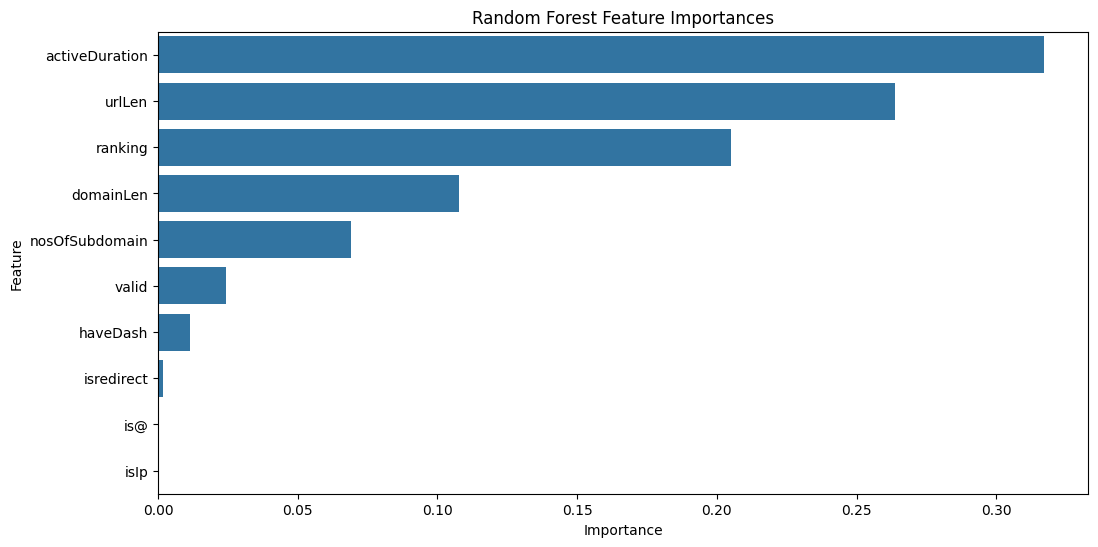

In [ ]:
# Feature importance from Random Forest
rf_feature_importances = best_rf_model.feature_importances_
rf_feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances for Random Forest
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance_df)
plt.title('Random Forest Feature Importances')
plt.show()

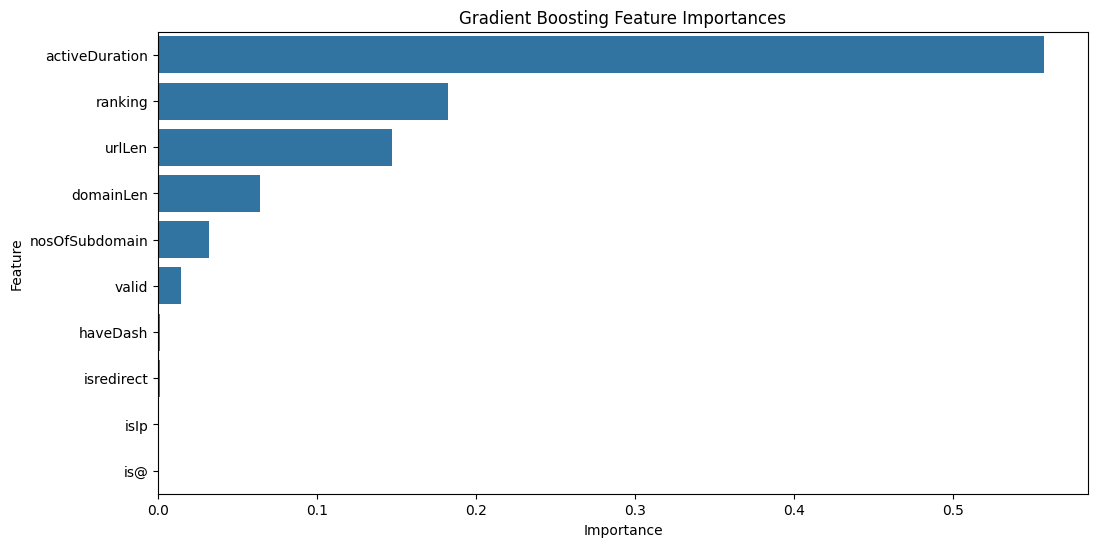

In [ ]:
# Feature importance from Gradient Boosting
gb_feature_importances = best_gb_model.feature_importances_
gb_feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances for Gradient Boosting
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=gb_feature_importance_df)
plt.title('Gradient Boosting Feature Importances')
plt.show()

In [ ]:

# Obtain probabilities from each model
rf_probabilities = best_rf_model.predict_proba(X_test)[:, 1]
gb_probabilities = best_gb_model.predict_proba(X_test)[:, 1]
nn_probabilities = nn_model.predict(X_test)[:, 1]

# Combine the probabilities (simple averaging)
combined_probabilities = (rf_probabilities + gb_probabilities + nn_probabilities) / 3

# Convert combined probabilities to binary predictions
combined_predictions = [1 if prob > 0.5 else 0 for prob in combined_probabilities]

# Evaluate the combined model
print("Confusion Matrix:")
print(confusion_matrix(Y_test, combined_predictions))
print("\nClassification Report:")
print(classification_report(Y_test, combined_predictions))
print("\nAccuracy Score:")
print(accuracy_score(Y_test, combined_predictions))


900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Confusion Matrix:
[[11122   724]
 [  607 16320]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     11846
           1       0.96      0.96      0.96     16927

    accuracy                           0.95     28773
   macro avg       0.95      0.95      0.95     28773
weighted avg       0.95      0.95      0.95     28773


Accuracy Score:
0.9537413547422932


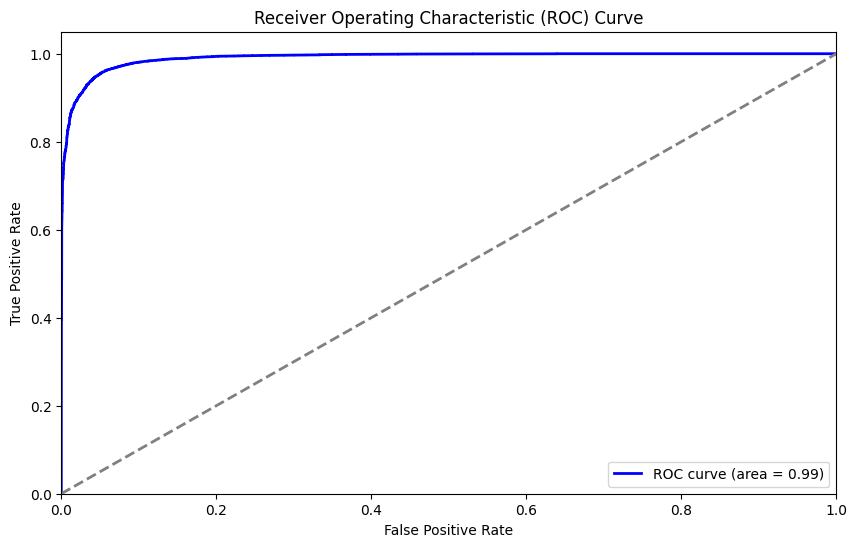

In [ ]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(Y_test, combined_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

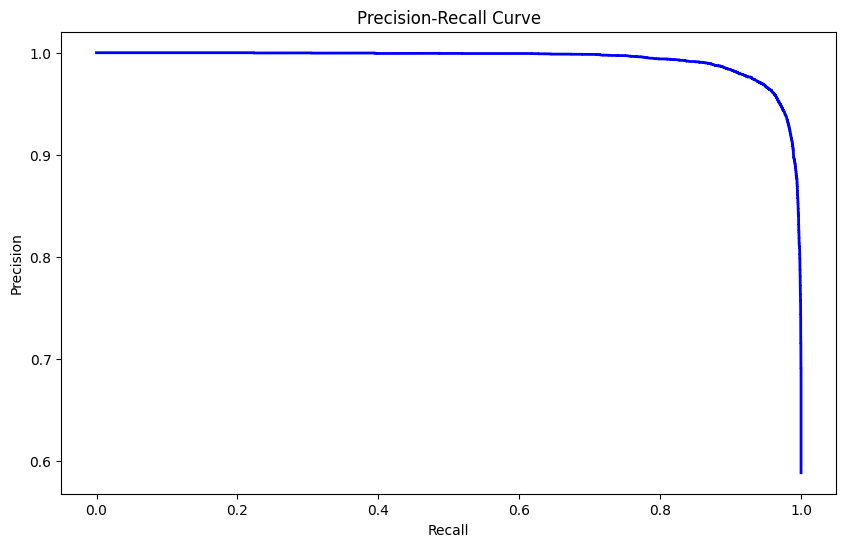

In [ ]:
# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(Y_test, combined_probabilities)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


#we get the output